# Student Performance Prediction

## Project Overview

This project analyzes student performance data and uses Machine Learning techniques to predict student outcomes.

The project includes:
- Data inspection and cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Linear Regression for predicting Final Score
- Classification for predicting Pass/Fail
- Decision Tree Classification
- Train/Test Split
- Model evaluation and comparison

The goal is to understand the factors that affect student performance and build simple Machine Learning models to make predictions.

In [27]:
# Import libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt

# Import Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Display plots inside the notebook
%matplotlib inline

In [28]:
# Create a larger student performance dataset
# The dataset intentionally contains missing values and duplicate rows
# so that we can practice real-world data cleaning.

data = {
    'Student_ID': [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015,
        1016, 1017, 1018, 1019, 1020,
        1021, 1022, 1023, 1024, 1025,
        1026, 1027, 1028, 1029, 1030,
        1031, 1032, 1033, 1034, 1035,
        1036, 1037, 1038, 1039, 1040,
        1041, 1042, 1043, 1044, 1045,
        1046, 1047, 1048, 1049, 1050
    ],

    'Study_Hours': [
        2.0, 3.5, 4.0, 5.0, 6.0,
        1.5, 7.0, 8.0, 3.0, 5.5,
        4.5, 6.5, 2.5, 9.0, 7.5,
        3.5, 5.0, 8.5, 4.0, 6.0,
        2.0, 7.0, 5.5, 3.0, 8.0,
        4.5, 6.5, 2.5, 9.0, 7.5,
        3.0, 5.0, 8.0, 4.0, 6.0,
        2.5, 7.5, 5.5, 3.5, 8.5,
        4.0, 6.0, 2.0, 9.5, 7.0,
        3.0, 5.5, 8.0, 4.5, 6.5
    ],

    'Attendance': [
        65, 70, 75, 80, 85,
        55, 90, 95, 68, 78,
        72, 88, 60, 98, 92,
        67, 76, 94, 73, 82,
        64, 89, 79, 69, 96,
        74, 86, 61, 99, 91,
        66, 77, 93, 71, 84,
        58, 87, 81, 63, 97,
        75, 83, 59, 100, 90,
        68, 78, 95, 72, 85
    ],

    'Previous_Score': [
        50, 55, 60, 65, 70,
        45, 75, 80, 58, 68,
        62, 72, 52, 85, 78,
        56, 67, 82, 61, 73,
        48, 77, 69, 54, 88,
        63, 74, 49, 91, 79,
        57, 66, 84, 59, 71,
        43, 76, 68, 51, 87,
        64, 70, 46, 93, 81,
        55, 73, 86, 60, 75
    ],

    'Final_Score': [
        54, 60, 65, 70, 76,
        48, 82, 88, 62, 73,
        68, 79, 57, 93, 85,
        61, 72, 90, 66, 80,
        52, 81, 74, 58, 91,
        69, 78, 55, 96, 86,
        60, 71, 89, 64, 77,
        45, 83, 75, 56, 92,
        70, 82, 50, 98, 88,
        59, 76, 94, 67, 81
    ]
}

# Convert the dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# Add missing values intentionally
df.loc[7, 'Attendance'] = np.nan
df.loc[14, 'Previous_Score'] = np.nan
df.loc[25, 'Study_Hours'] = np.nan
df.loc[38, 'Final_Score'] = np.nan
df.loc[46, 'Attendance'] = np.nan

# Add duplicate rows intentionally
df = pd.concat([
    df,
    df.iloc[[10, 25, 35]]
], ignore_index=True)

# Display the dataset
df

,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
0,1001,2.0,65.0,50.0,54.0
1,1002,3.5,70.0,55.0,60.0
2,1003,4.0,75.0,60.0,65.0
3,1004,5.0,80.0,65.0,70.0
4,1005,6.0,85.0,70.0,76.0
5,1006,1.5,55.0,45.0,48.0
6,1007,7.0,90.0,75.0,82.0
7,1008,8.0,NaN,80.0,88.0
8,1009,3.0,68.0,58.0,62.0
9,1010,5.5,78.0,68.0,73.0


## 4. Initial Data Inspection

Before building Machine Learning models, we need to understand the structure and quality of the dataset.

In [29]:
# Display the first five rows of the dataset
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
0,1001,2.0,65.0,50.0,54.0
1,1002,3.5,70.0,55.0,60.0
2,1003,4.0,75.0,60.0,65.0
3,1004,5.0,80.0,65.0,70.0
4,1005,6.0,85.0,70.0,76.0


In [30]:
# Display the number of rows and columns
df.shape

(53, 5)

In [31]:
# Display information about columns, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      53 non-null     int64  
 1   Study_Hours     51 non-null     float64
 2   Attendance      51 non-null     float64
 3   Previous_Score  52 non-null     float64
 4   Final_Score     52 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.2 KB


In [32]:
# Generate descriptive statistics for numerical columns
df.describe()

,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
count,53.000000,51.000000,51.000000,52.000000,52.000000
mean,1025.433962,5.294118,78.117647,66.557692,72.538462
std,14.366774,2.202672,12.431648,13.188547,13.988036
min,1001.000000,1.500000,55.000000,43.000000,45.000000
25%,1013.000000,3.500000,68.500000,56.750000,61.750000
50%,1026.000000,5.500000,77.000000,66.500000,72.500000
75%,1037.000000,7.000000,88.500000,75.250000,82.250000
max,1050.000000,9.500000,100.000000,93.000000,98.000000


In [16]:
# Check the number of missing values in each column
df.isnull().sum()

Student_ID        0
Study_Hours       2
Attendance        2
Previous_Score    1
Final_Score       1
dtype: int64

In [17]:
# Check the number of duplicate rows
df.duplicated().sum()

np.int64(3)

## 5. Data Cleaning

Before applying Machine Learning models, we need to clean the dataset.

In this step, we will:
- Identify missing values.
- Handle missing numerical values using the median.
- Remove duplicate rows.
- Verify that the dataset is clean.

In [33]:
# Display rows that contain missing values
missing_rows = df[df.isnull().any(axis=1)]

print("Rows containing missing values:")
missing_rows

Rows containing missing values:


,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
7,1008,8.0,NaN,80.0,88.0
14,1015,7.5,92.0,NaN,85.0
25,1026,NaN,74.0,63.0,69.0
38,1039,3.5,63.0,51.0,NaN
46,1047,5.5,NaN,73.0,76.0
51,1026,NaN,74.0,63.0,69.0


In [34]:
# Calculate the median of the numerical columns
print("Study Hours Median:", df['Study_Hours'].median())
print("Attendance Median:", df['Attendance'].median())
print("Previous Score Median:", df['Previous_Score'].median())
print("Final Score Median:", df['Final_Score'].median())

Study Hours Median: 5.5
Attendance Median: 77.0
Previous Score Median: 66.5
Final Score Median: 72.5


In [35]:
# Fill missing values with the median of each column
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())

df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

df['Previous_Score'] = df['Previous_Score'].fillna(df['Previous_Score'].median())

df['Final_Score'] = df['Final_Score'].fillna(df['Final_Score'].median())

# Check missing values after imputation
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Student_ID        0
Study_Hours       0
Attendance        0
Previous_Score    0
Final_Score       0
dtype: int64


## 6. Removing Duplicate Rows

Duplicate records can affect the analysis and Machine Learning models.

We will identify and remove duplicate rows before continuing with the analysis.

In [36]:
# Count duplicate rows before removing them
duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal: 3


In [37]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Check the number of duplicate rows after removal
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


## 7. Final Data Cleaning Verification

After handling missing values and duplicate rows, we verify that the dataset is ready for analysis and Machine Learning.

In [38]:
# Verify that no missing values remain
print("Missing Values:")
print(df.isnull().sum())

# Verify that no duplicate rows remain
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Display the final shape of the cleaned dataset
print("\nDataset Shape:")
print(df.shape)

Missing Values:
Student_ID        0
Study_Hours       0
Attendance        0
Previous_Score    0
Final_Score       0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
(50, 5)


In [39]:
df

,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
0,1001,2.0,65.0,50.0,54.0
1,1002,3.5,70.0,55.0,60.0
2,1003,4.0,75.0,60.0,65.0
3,1004,5.0,80.0,65.0,70.0
4,1005,6.0,85.0,70.0,76.0
5,1006,1.5,55.0,45.0,48.0
6,1007,7.0,90.0,75.0,82.0
7,1008,8.0,77.0,80.0,88.0
8,1009,3.0,68.0,58.0,62.0
9,1010,5.5,78.0,68.0,73.0


## 8. Exploratory Data Analysis (EDA)

In this section, we explore the cleaned dataset to understand the relationships between study habits, attendance, previous performance, and final scores.

The main questions we want to answer are:

- Does studying more lead to a higher Final Score?
- Does Attendance affect student performance?
- Is Previous Score related to Final Score?
- Which features have the strongest relationship with Final Score?

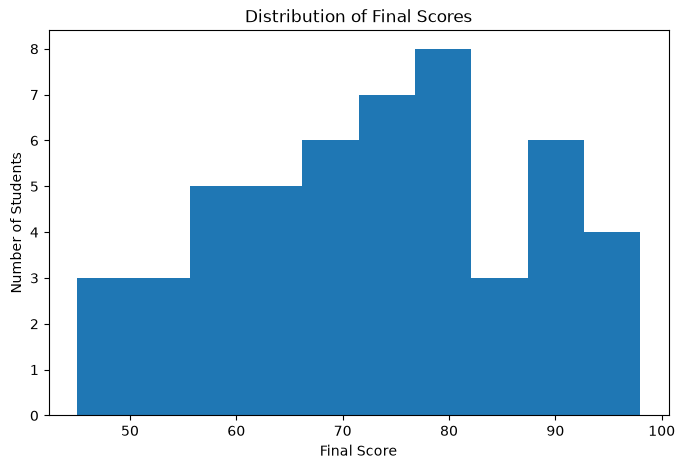

In [40]:
# Plot the distribution of students' final scores
plt.figure(figsize=(8, 5))

plt.hist(df['Final_Score'], bins=10)

plt.xlabel('Final Score')
plt.ylabel('Number of Students')
plt.title('Distribution of Final Scores')

plt.show()

### Study Hours vs Final Score

We investigate whether students who study more hours tend to achieve higher final scores.

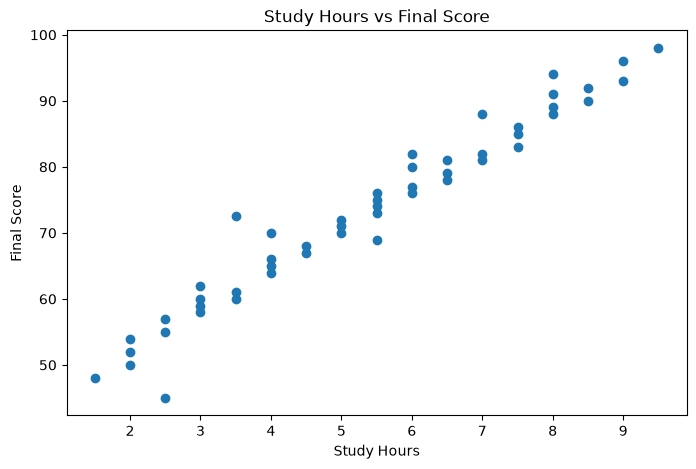

In [41]:
# Plot the relationship between study hours and final score
plt.figure(figsize=(8, 5))

plt.scatter(df['Study_Hours'], df['Final_Score'])

plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')

plt.show()

### Attendance vs Final Score

We investigate whether students with higher attendance tend to achieve higher final scores.

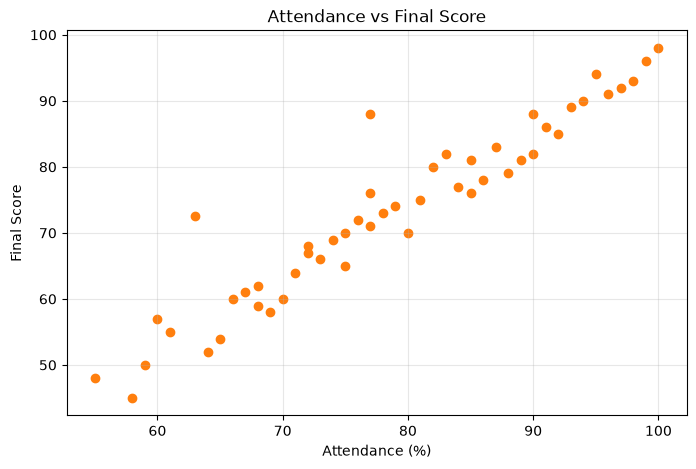

In [42]:
# Plot the relationship between attendance and final score
plt.figure(figsize=(8, 5))
plt.scatter(df['Attendance'], df['Final_Score'], color='tab:orange')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.title('Attendance vs Final Score')
plt.grid(alpha=0.3)
plt.show()

### Previous Score vs Final Score

We also compare each student's previous score with their final score.

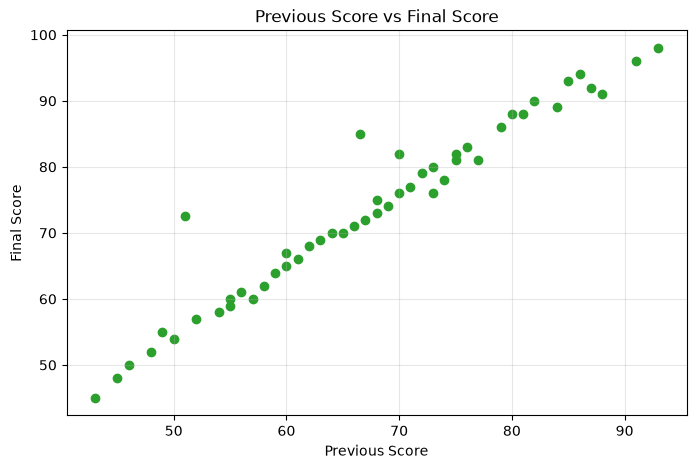

In [43]:
# Plot the relationship between previous score and final score
plt.figure(figsize=(8, 5))
plt.scatter(df['Previous_Score'], df['Final_Score'], color='tab:green')
plt.xlabel('Previous Score')
plt.ylabel('Final Score')
plt.title('Previous Score vs Final Score')
plt.grid(alpha=0.3)
plt.show()

### Correlation Analysis

Correlation helps us measure the strength and direction of the linear relationship between numerical variables.

Correlation with Final Score:
Final_Score       1.000000
Study_Hours       0.975547
Previous_Score    0.969423
Attendance        0.950212
Name: Final_Score, dtype: float64


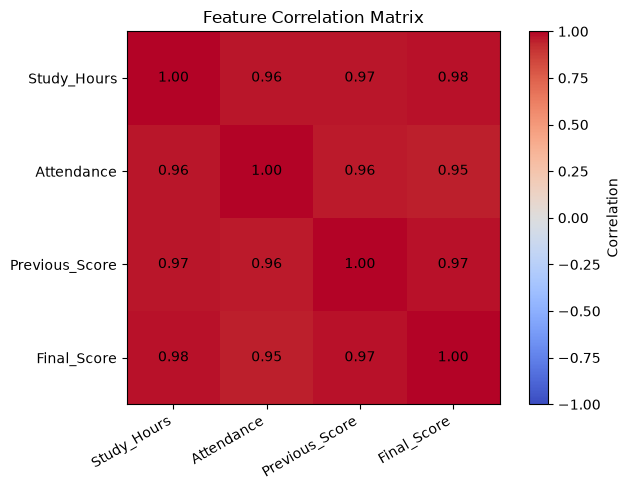

In [44]:
# Calculate correlations between the numerical variables
correlation_matrix = df[['Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score']].corr()
print('Correlation with Final Score:')
print(correlation_matrix['Final_Score'].sort_values(ascending=False))

# Visualize the correlation matrix without additional libraries
plt.figure(figsize=(7, 5))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=30, ha='right')
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
for row in range(len(correlation_matrix.index)):
    for col in range(len(correlation_matrix.columns)):
        plt.text(col, row, f"{correlation_matrix.iloc[row, col]:.2f}", ha='center', va='center')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Machine Learning

We will build two types of models:

- **Linear Regression** to predict the exact Final Score.
- **Classification models** to predict whether a student passes (Final Score >= 60).

`Student_ID` is an identifier, not a meaningful learning feature, so it is excluded from the models.

In [45]:
# Define input features and the regression target
feature_columns = ['Study_Hours', 'Attendance', 'Previous_Score']
X = df[feature_columns]
y_regression = df['Final_Score']

# Use the same split for a fair comparison between models
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.20, random_state=42
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (40, 3)
Test set shape: (10, 3)


### Linear Regression: Predicting Final Score

In [46]:
# Train a linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train_reg)

# Make predictions and evaluate the regression model
y_pred_reg = linear_model.predict(X_test)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

# Compare actual and predicted final scores
results_regression = pd.DataFrame({
    'Actual Final Score': y_test_reg.values,
    'Predicted Final Score': y_pred_reg.round(2)
})
results_regression

Mean Absolute Error: 1.49
Root Mean Squared Error: 1.80
R-squared: 0.98


,Actual Final Score,Predicted Final Score
0,93.0,94.87
1,92.0,93.58
2,60.0,60.02
3,59.0,59.37
4,90.0,91.68
5,67.0,67.23
6,78.0,80.64
7,69.0,72.32
8,89.0,90.39
9,80.0,78.16


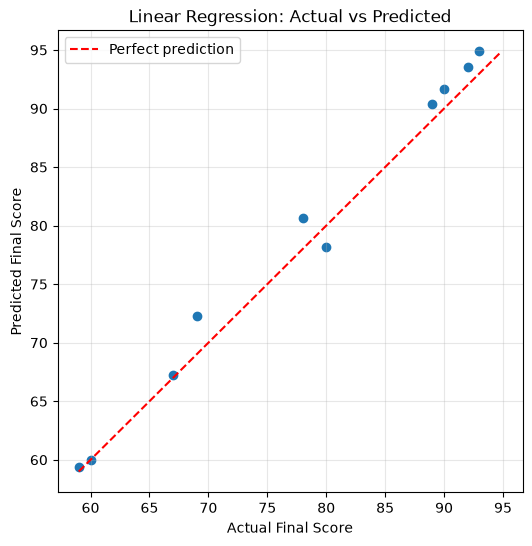

In [47]:
# Visualize actual versus predicted scores
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, color='tab:blue')
limits = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
plt.plot(limits, limits, 'r--', label='Perfect prediction')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Classification: Predicting Pass or Fail

In [48]:
# Create a binary target: 1 = Pass, 0 = Fail
df['Pass_Fail'] = (df['Final_Score'] >= 60).astype(int)
print(df['Pass_Fail'].value_counts().rename(index={0: 'Fail', 1: 'Pass'}))

# Split the features and classification target; stratify preserves class balance
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, df['Pass_Fail'], test_size=0.20, random_state=42, stratify=df['Pass_Fail']
)

Pass_Fail
Pass    41
Fail     9
Name: count, dtype: int64


In [49]:
# Train and evaluate Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_cls, y_train_cls)
y_pred_logistic = logistic_model.predict(X_test_cls)

print('Logistic Regression Accuracy:', f'{accuracy_score(y_test_cls, y_pred_logistic):.2%}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_logistic, target_names=['Fail', 'Pass'], zero_division=0))

Logistic Regression Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         8

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [50]:
# Train and evaluate a Decision Tree classifier
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_cls, y_train_cls)
y_pred_tree = tree_model.predict(X_test_cls)

print('Decision Tree Accuracy:', f'{accuracy_score(y_test_cls, y_pred_tree):.2%}')
print('\nClassification Report:')
print(classification_report(y_test_cls, y_pred_tree, target_names=['Fail', 'Pass'], zero_division=0))

Decision Tree Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         8

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



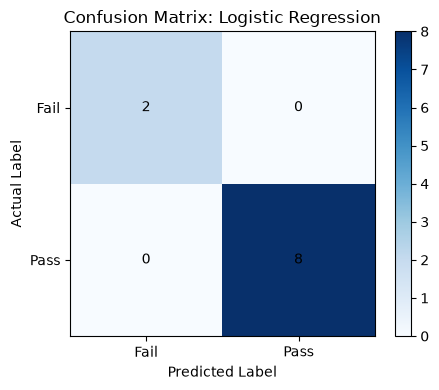

In [51]:
# Compare the two classification models
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test_cls, y_pred_logistic),
        accuracy_score(y_test_cls, y_pred_tree)
    ]
})
model_comparison

# Confusion matrix for the better model on this test split
best_predictions = y_pred_logistic if model_comparison.loc[0, 'Accuracy'] >= model_comparison.loc[1, 'Accuracy'] else y_pred_tree
best_model_name = model_comparison.loc[model_comparison['Accuracy'].idxmax(), 'Model']
cm = confusion_matrix(y_test_cls, best_predictions)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix: {best_model_name}')
for row in range(2):
    for col in range(2):
        plt.text(col, row, cm[row, col], ha='center', va='center')
plt.tight_layout()
plt.show()

## 10. Conclusion

This project followed a complete data-science workflow: data inspection, missing-value treatment, duplicate removal, verification, EDA, visualization, and machine learning. The regression model estimates a student's final score, while the classification models predict pass/fail from study hours, attendance, and previous score.

Because this is a small synthetic dataset, the metrics are mainly a demonstration of the workflow. A real project should validate results with more observations and additional relevant features.